# Fourier Ptychography (FPM) Reconstruction

This notebook demonstrates **Fourier ptychographic microscopy (FPM)** reconstruction
using the [PtyLab](https://github.com/PtyLab/PtyLab.py) toolbox,
reproducing the FPM example from Loetgering et al., *Opt. Express* **31**, 13763 (2023).

## What is Fourier Ptychography?

FPM achieves **simultaneous high resolution and wide field of view** — two normally
conflicting requirements — by computationally stitching together low-resolution images
captured under different LED illumination angles.

Each LED illuminates the sample from a different angle, shifting the object's spectrum
to a different region in k-space. By choosing LED angles such that adjacent k-space
regions **overlap**, we can perform phase retrieval and super-resolution reconstruction.

```
   LED array (11×11, z=60mm)
         ↓  angle-dependent illumination
   [sample O(r)]  ──── lens (NA=0.1, M=4×) ────  camera (256×256 px)
                        pupil P̃(q)                 I_j(r)
```

## Experimental Parameters

| Parameter | Value |
|---|---|
| Wavelength λ | 625 nm (red LED) |
| Numerical aperture | NA = 0.1 |
| Magnification | 4× |
| Camera pixel size dxd | 6.5 μm |
| Object pixel size dxp | 1.625 μm |
| Low-res image size | 256 × 256 px |
| High-res object size | ~730 × 730 px (dynamically computed by PtyLab from LED range) |
| LED array | 11×11 grid, pitch 2 mm, z = 60 mm |
| Valid LEDs | 121 (all 11×11 LEDs within k-space bounds) |
| Super-resolution factor | ~2.9× |
| Solver | mqNewton (200 iterations, NADAM) |


## Forward Model

For LED **j** at position **(u_x, u_y)** from the optical axis at height z_led,
the illumination angle is **sin θ ≈ u/z_led**. This shifts the object spectrum
under the pupil bandpass:

$$I_j(\mathbf{r}) = \left|\mathcal{F}\!\left\{\tilde{P}(\mathbf{q}) \cdot \tilde{O}(\mathbf{q} - \mathbf{q}_j)\right\}\right|^2$$

where:
- **Õ(q)** = FT{O(r)} is the object spectrum (high-resolution)
- **P̃(q)** is the pupil function (circle of radius NA/λ in k-space)
- **q_j** is the k-space shift for LED j, computed via the exact formula:

$$\Delta k_j = -\frac{1}{\lambda} \cdot d_{xp} \cdot N_d \cdot \frac{\mathbf{u}_j}{\|\mathbf{u}_j, z_\text{led}\|}$$

where N_d is the detector size in pixels and the denominator is the 3D LED-to-sample distance.

The maximum recoverable spatial frequency (super-resolution bound):
$$k_{max} = \frac{2\pi}{\lambda}(\mathrm{NA} + \sin\theta_{max})$$

where sin θ_max is determined by the outermost LED angle.

**Key difference from CP**: in FPM the probe P̃ lives in **k-space** (not real space),
and the forward model uses an **FFT** (Fraunhofer propagator) from k-space to the image plane.
`reconstruction.object` is stored in k-space; `fft2c(object)` gives the spatially-reversed
real-space image.


In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import h5py
import json

import logging
logging.getLogger().setLevel(logging.ERROR)

print("Imports OK")

Imports OK


## 1. Raw Data

In [2]:
DATA_DIR   = '../data'
RECON_PATH = '../evaluation/reference_outputs/recon.hdf5'
META_PATH  = '../data/meta_data.json'

with open(META_PATH) as f:
    meta = json.load(f)

npz          = np.load(f'{DATA_DIR}/raw_data.npz')
ptychogram   = npz['ptychogram']    # (121, 256, 256) float32
encoder      = npz['encoder']       # (121, 2) float32 — LED positions [m]

wavelength    = meta['wavelength_m']
z_led         = meta['z_led_m']
dxd           = meta['dxd_m']
NA            = meta['NA']
magnification = meta['magnification']

dxp = dxd / magnification
Nd  = ptychogram.shape[-1]
num_leds = len(encoder)

print(f"Ptychogram: {ptychogram.shape}, dtype={ptychogram.dtype}")
print(f"  min={ptychogram.min():.1f}, max={ptychogram.max():.1f}")
print(f"LED positions: {encoder.shape}  ({num_leds} LEDs)")
print(f"Wavelength: {wavelength*1e9:.0f} nm")
print(f"LED-to-sample distance: {z_led*1e3:.0f} mm")
print(f"NA={NA}, magnification={magnification}×")
print(f"Object pixel size dxp: {dxp*1e6:.3f} μm")

Ptychogram: (121, 256, 256), dtype=float32
  min=0.0, max=1066.0
LED positions: (121, 2)  (121 LEDs)
Wavelength: 625 nm
LED-to-sample distance: 60 mm
NA=0.1, magnification=4.0×
Object pixel size dxp: 1.625 μm


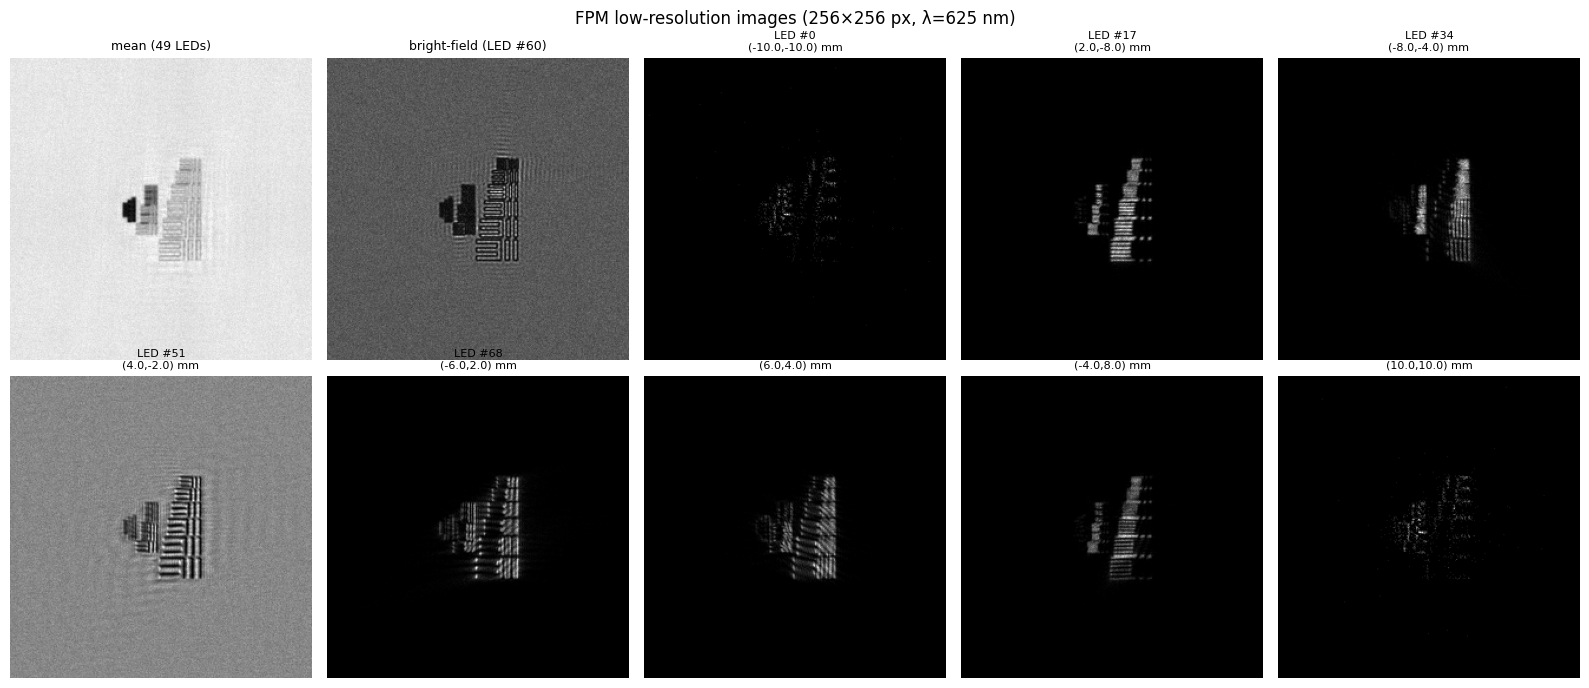

In [3]:
# Mean image, bright-field image, and 6 individual LED images
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.ravel()

# Mean of all 49 images
axes[0].imshow(ptychogram.mean(axis=0), cmap='gray')
axes[0].set_title('mean (49 LEDs)', fontsize=9)
axes[0].axis('off')

# Bright-field (highest total intensity = on-axis LED)
bf_idx = np.argmax(ptychogram.sum(axis=(1, 2)))
axes[1].imshow(ptychogram[bf_idx], cmap='gray')
axes[1].set_title(f'bright-field (LED #{bf_idx})', fontsize=9)
axes[1].axis('off')

# 8 individual images evenly spaced (mix of bright- and dark-field)
sample_idx = np.linspace(0, num_leds-1, 8, dtype=int)
for i, idx in enumerate(sample_idx):
    ax = axes[i+2]
    ax.imshow(ptychogram[idx], cmap='gray')
    ux, uy = encoder[idx, 1]*1e3, encoder[idx, 0]*1e3
    ax.set_title(f'LED #{idx}\n({ux:.1f},{uy:.1f}) mm', fontsize=8)
    ax.axis('off')

fig.suptitle(
    f'FPM low-resolution images ({Nd}×{Nd} px, λ={wavelength*1e9:.0f} nm)',
    fontsize=12
)
plt.tight_layout()
plt.show()

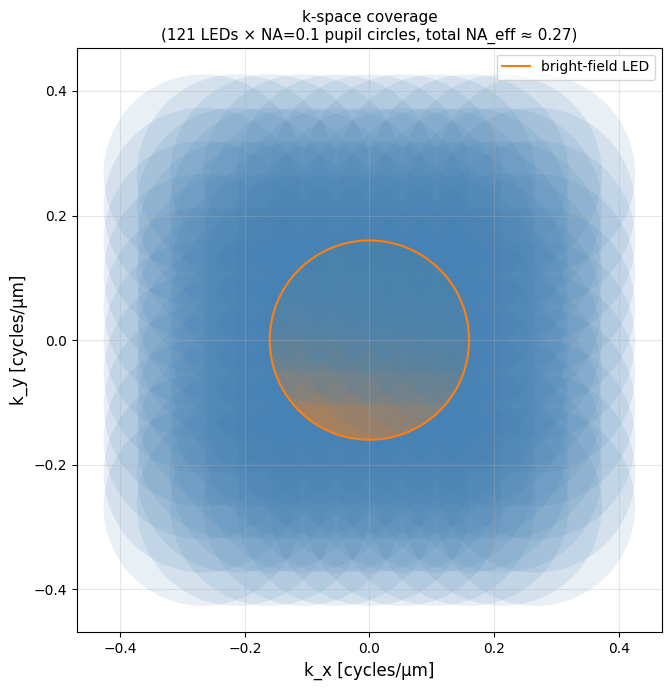

Bright-field NA: 0.1
Effective NA (outermost LED): 0.267
Super-resolution factor: 2.67×


In [4]:
# k-space coverage diagram
# Each LED illuminates a shifted circular region of the object spectrum
# Pupil radius in object-plane spatial-frequency units (cycles/μm)
f_cutoff = NA / wavelength * 1e-6   # cycles/μm

# LED k-space shifts in cycles/μm
# q_j = sin(theta_j) / lambda = (u_j/z_led) / lambda
shifts = encoder / (wavelength * z_led)   # (J, 2) in m^{-1}
shifts_um = shifts * 1e-6                  # cycles/μm

fig, ax = plt.subplots(figsize=(7, 7))

# Draw pupil circles for each LED
theta = np.linspace(0, 2*np.pi, 200)
for i, (sy, sx) in enumerate(shifts_um):
    alpha = 0.12 if i != bf_idx else 0.5
    color = 'steelblue' if i != bf_idx else 'tab:orange'
    ax.fill(sx + f_cutoff*np.cos(theta), sy + f_cutoff*np.sin(theta),
            alpha=alpha, color=color, linewidth=0)

# Highlight bright-field circle
sy, sx = shifts_um[bf_idx]
ax.plot(sx + f_cutoff*np.cos(theta), sy + f_cutoff*np.sin(theta),
        color='tab:orange', lw=1.5, label='bright-field LED')

ax.set_aspect('equal')
ax.set_xlabel('k_x [cycles/μm]', fontsize=12)
ax.set_ylabel('k_y [cycles/μm]', fontsize=12)
encoder_range = encoder.max(axis=0) - encoder.min(axis=0)
na_eff_approx = NA + encoder_range.max() / (2 * z_led)
ax.set_title(
    f'k-space coverage\n'
    f'({num_leds} LEDs × NA={NA} pupil circles, total NA_eff ≈ {na_eff_approx:.2f})',
    fontsize=11
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

na_eff = NA + (np.abs(encoder)).max() / z_led
print(f"Bright-field NA: {NA}")
print(f"Effective NA (outermost LED): {na_eff:.3f}")
print(f"Super-resolution factor: {na_eff/NA:.2f}×")


## 2. Algorithm: qNewton

### PIE-type update (per LED j)

In FPM the object **spectrum** Õ(q) is updated, not the real-space object:

$$\tilde{O}_{n+1}(\mathbf{q} - \mathbf{q}_j) = \tilde{O}_n(\mathbf{q} - \mathbf{q}_j)
  + \beta_O \frac{\tilde{P}_n^*(\mathbf{q})}{\max|\tilde{P}_n|^2}
  \left(\hat{\psi}_j - \psi_j\right)$$

$$\tilde{P}_{n+1}(\mathbf{q}) = \tilde{P}_n(\mathbf{q})
  + \beta_P \frac{\tilde{O}_j^*(\mathbf{q})}{\max|\tilde{O}_j|^2}
  \left(\hat{\psi}_j - \psi_j\right)$$

where the constrained wave is:
$$\hat{\psi}_j(\mathbf{r}) = \sqrt{I_j(\mathbf{r})} \cdot \frac{\psi_j}{|\psi_j|}$$

**Note**: FPM uses PIE (not ePIE) because ePIE concentrates updates near the pupil maximum,
which would favor bright-field over dark-field — PIE spreads updates uniformly.

### Quasi-Newton step (qNewton)

qNewton uses the Hessian approximation from the k-space intensity patterns to scale the
PIE gradient step, resulting in faster convergence than plain PIE without requiring a
momentum buffer. Unlike mqNewton (which adds NADAM momentum on top), qNewton applies
only the Hessian-scaled gradient step — this gives **monotonically decreasing error**
and is well-suited for simulated data where the positions and parameters are exact.

### LED ordering

Positions sorted by NA (bright-field first, dark-field last).
This ensures stable convergence: the bright-field images provide a good initial
estimate which is then refined by dark-field.


## 3. Reconstruction Results

In [5]:
with h5py.File(RECON_PATH, 'r') as f:
    obj   = np.squeeze(f['object'][:])   # (No, No) complex64
    pupil = np.squeeze(f['probe'][:])    # (Nd, Nd) complex64
    error = f['error'][:]                 # (200,) float
    dxp_recon = float(np.ravel(f['dxp'][:])[0])

with open('../evaluation/reference_outputs/metrics.json') as f:
    metrics = json.load(f)

No = obj.shape[0]
print(f"Reconstructed object: {obj.shape}, dtype={obj.dtype}")
print(f"Reconstructed pupil:  {pupil.shape}")
print(f"Error history:        {len(error)} iterations")
print(f"Object pixel size:    {dxp_recon*1e6:.3f} μm")
print(f"Object FOV:           {No*dxp_recon*1e3:.2f} mm × {No*dxp_recon*1e3:.2f} mm")

Reconstructed object: (730, 730), dtype=complex64
Reconstructed pupil:  (256, 256)
Error history:        200 iterations
Object pixel size:    1.625 μm
Object FOV:           1.19 mm × 1.19 mm


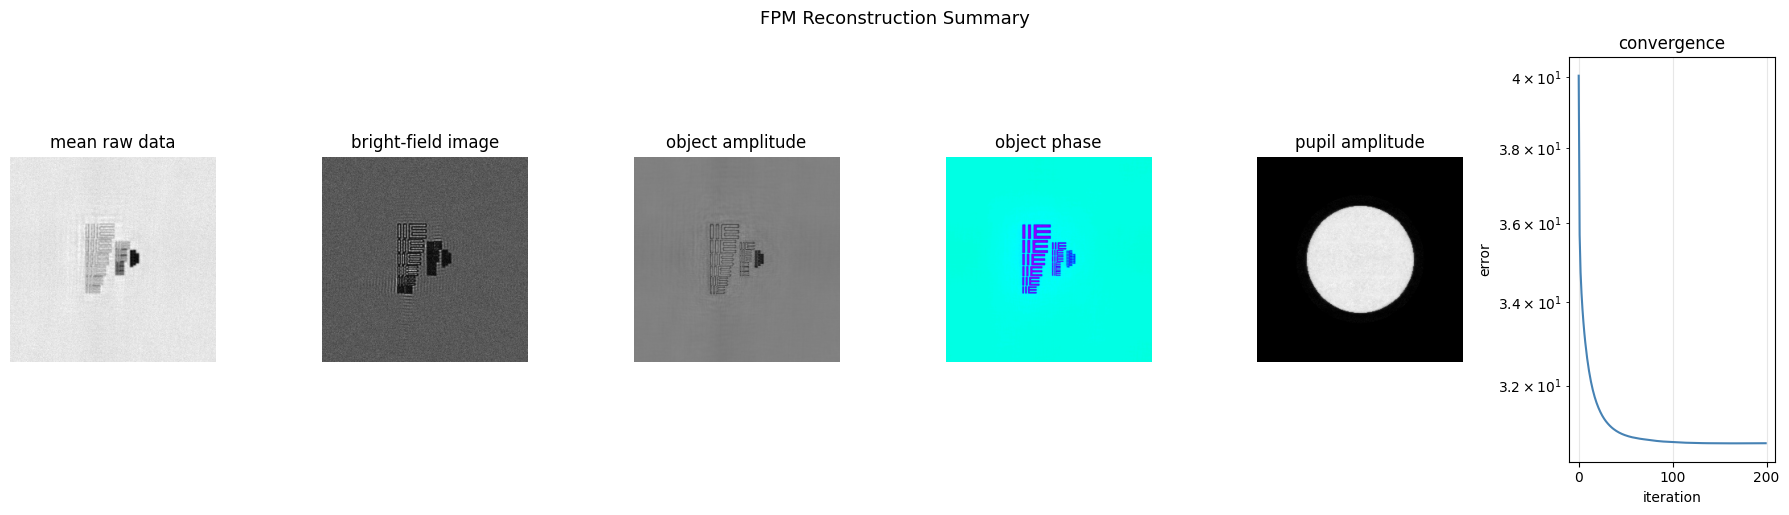

In [6]:
from src.visualization import plot_reconstruction_summary, get_object_realspace, get_pupil

# Build a minimal mock reconstruction object for the visualization function
class MockRecon:
    def __init__(self, obj, pupil):
        self.object = obj[np.newaxis, np.newaxis, np.newaxis, np.newaxis]
        self.probe  = pupil[np.newaxis, np.newaxis, np.newaxis, np.newaxis]

class MockExpData:
    def __init__(self, ptychogram):
        self.ptychogram = ptychogram
from src.utils import ifft2c        
obj_image = ifft2c(obj)
mock_recon    = MockRecon(obj, pupil )
mock_exp_data = MockExpData(ptychogram)

fig = plot_reconstruction_summary(
    mock_recon, mock_exp_data, error.tolist(), figsize=(18, 5)
)
plt.suptitle('FPM Reconstruction Summary', fontsize=13, y=1.02)
plt.show()

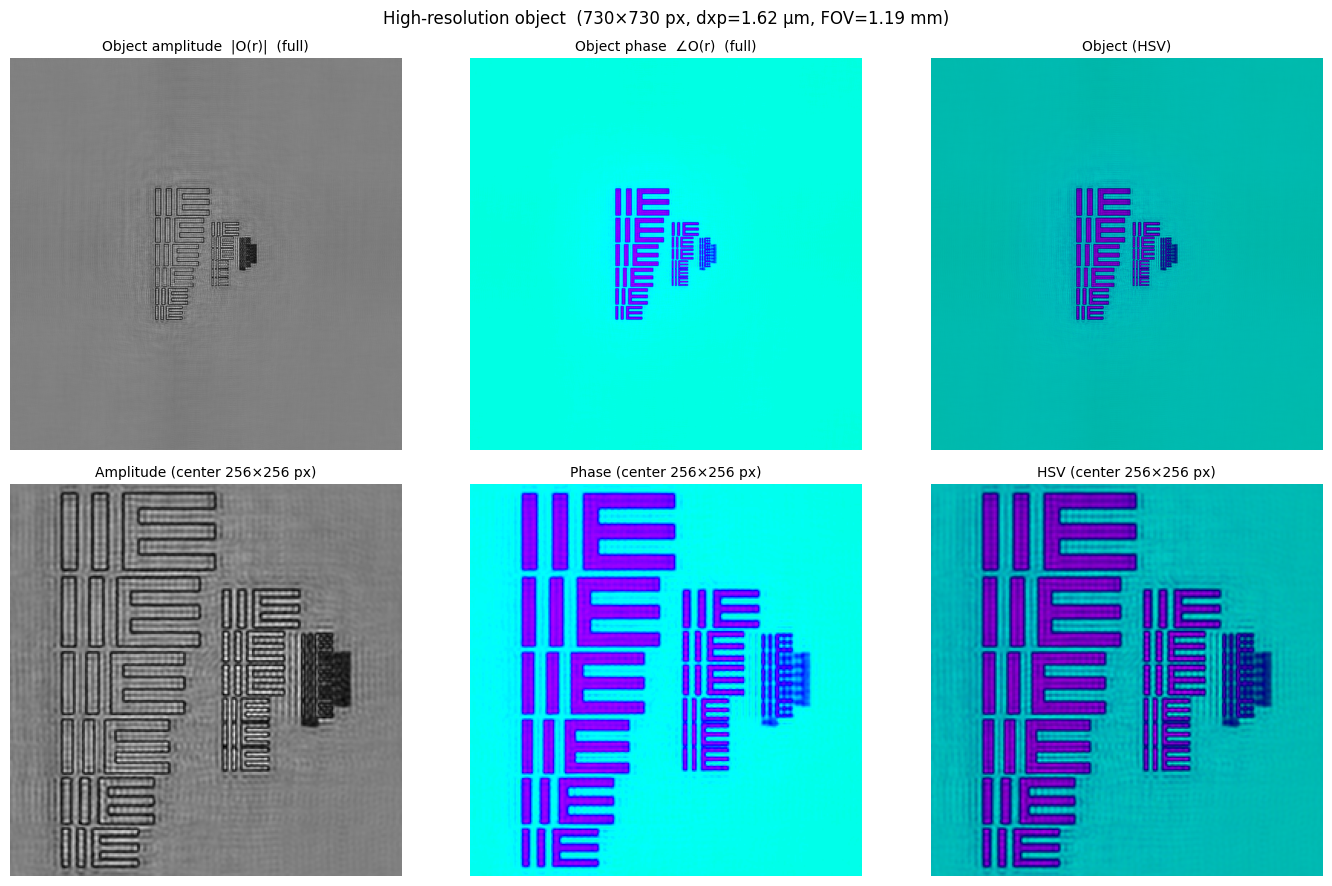

In [7]:
# Object amplitude and phase side-by-side (full and cropped center)
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

# Full object
axes[0, 0].imshow(np.abs(obj_image), cmap='gray')
axes[0, 0].set_title('Object amplitude  |O(r)|  (full)', fontsize=10)
axes[0, 0].axis('off')

axes[0, 1].imshow(np.angle(obj_image), cmap='hsv', vmin=-np.pi, vmax=np.pi)
axes[0, 1].set_title('Object phase  ∠O(r)  (full)', fontsize=10)
axes[0, 1].axis('off')

# HSV complex
from src.visualization import complex_to_hsv
rgb = complex_to_hsv(obj_image)
axes[0, 2].imshow(rgb)
axes[0, 2].set_title('Object (HSV)', fontsize=10)
axes[0, 2].axis('off')

# Cropped center (central 256×256)
c = No // 2
hw = 128
crop_amp   = np.abs(obj_image)[c-hw:c+hw, c-hw:c+hw]
crop_phase = np.angle(obj_image)[c-hw:c+hw, c-hw:c+hw]
crop_obj   = obj_image[c-hw:c+hw, c-hw:c+hw]

axes[1, 0].imshow(crop_amp, cmap='gray')
axes[1, 0].set_title(f'Amplitude (center {2*hw}×{2*hw} px)', fontsize=10)
axes[1, 0].axis('off')

axes[1, 1].imshow(crop_phase, cmap='hsv', vmin=-np.pi, vmax=np.pi)
axes[1, 1].set_title(f'Phase (center {2*hw}×{2*hw} px)', fontsize=10)
axes[1, 1].axis('off')

axes[1, 2].imshow(complex_to_hsv(crop_obj))
axes[1, 2].set_title(f'HSV (center {2*hw}×{2*hw} px)', fontsize=10)
axes[1, 2].axis('off')

fig.suptitle(
    f'High-resolution object  ({No}×{No} px, dxp={dxp_recon*1e6:.2f} μm, '
    f'FOV={No*dxp_recon*1e3:.2f} mm)',
    fontsize=12
)
plt.tight_layout()
plt.show()

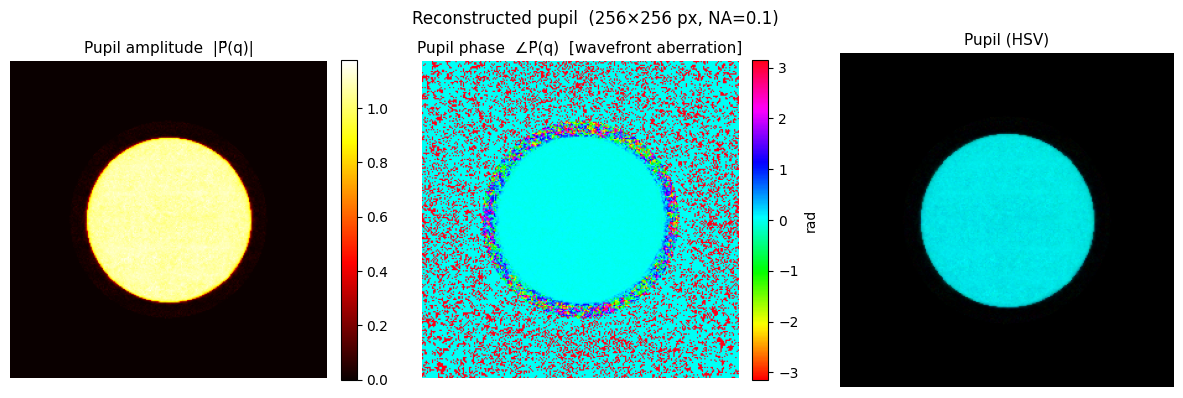

In [8]:
# Pupil function (should be a circle of radius NA in k-space)
# pupil_shifted = np.fft.fftshift(pupil)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

im0 = axes[0].imshow(np.abs(pupil), cmap='hot')
axes[0].set_title('Pupil amplitude  |P̃(q)|', fontsize=11)
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(np.angle(pupil), cmap='hsv', vmin=-np.pi, vmax=np.pi)
axes[1].set_title('Pupil phase  ∠P̃(q)  [wavefront aberration]', fontsize=11)
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label='rad')

axes[2].imshow(complex_to_hsv(pupil))
axes[2].set_title('Pupil (HSV)', fontsize=11)
axes[2].axis('off')

fig.suptitle(
    f'Reconstructed pupil  ({pupil.shape[0]}×{pupil.shape[1]} px, NA={NA})',
    fontsize=12
)
plt.tight_layout()
plt.show()

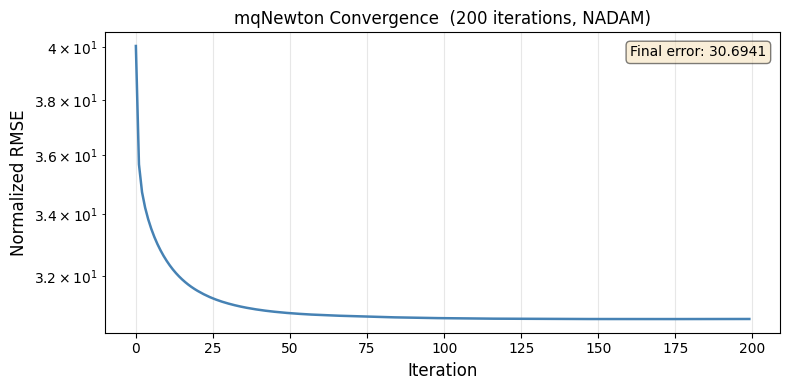

In [9]:
# Convergence
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(error, color='steelblue', lw=1.8)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Normalized RMSE', fontsize=12)
ax.set_title('mqNewton Convergence  (200 iterations, NADAM)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.text(0.98, 0.92, f'Final error: {error[-1]:.4f}',
        transform=ax.transAxes, ha='right', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.show()

## 4. Metrics Summary

In [10]:
print("=" * 55)
print("Reconstruction metrics")
print("=" * 55)
print(f"  Algorithm:          qNewton (PIE + quasi-Newton step)")
print(f"  Iterations:         {metrics['num_iterations']}")
print(f"  Wavelength:         {metrics['wavelength_nm']:.0f} nm")
print(f"  NA:                 {metrics['NA']}")
print(f"  Magnification:      {metrics['magnification']}×")
print(f"  Object shape:       {metrics['object_shape']}")
print(f"  Pupil shape:        {metrics['pupil_shape']}")
print(f"  Final error:        {error[-1]:.4f}")
print(f"  Object FOV:         {No*dxp_recon*1e3:.2f} mm × {No*dxp_recon*1e3:.2f} mm")
print(f"  Super-res factor:   {No/Nd:.1f}× (object/detector pixels)")
print(f"  Image Phase NCC:    {metrics.get('image_phase_ncc', 'N/A')}")
print(f"  Image Phase NRMSE:  {metrics.get('image_phase_nrmse', 'N/A')}")


Reconstruction metrics
  Algorithm:          qNewton (PIE + quasi-Newton step)
  Iterations:         200
  Wavelength:         625 nm
  NA:                 0.1
  Magnification:      4.0×
  Object shape:       [730, 730]
  Pupil shape:        [256, 256]
  Final error:        30.6941
  Object FOV:         1.19 mm × 1.19 mm
  Super-res factor:   2.9× (object/detector pixels)
  Image Phase NCC:    0.961
  Image Phase NRMSE:  0.046


## 5. Reconstruction Quality: Comparison with Ground Truth

Since this is a simulation with a USAF 1951 phase object, we have access to the ground truth.

**Domain note**: In PtyLab FPM, `reconstruction.object` is stored in **k-space** (the object spectrum K).
To compare with the real-space ground truth, convert back via the inverse Fourier transform:

$$K \approx \text{fft2c}(O) \quad \Rightarrow \quad O_{\text{recon}} = \text{ifft2c}(K)$$

This recovers the real-space image directly — no axis flipping required.

**Metrics (matching `metrics.json`):**
- **Phase NCC**: Pearson correlation of mean-subtracted phase maps — 1 = perfect
- **Phase NRMSE**: `‖∠O_recon − ∠O_GT‖ / std(∠O_GT)` — 0 = perfect


In [11]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from src.utils import ifft2c

# ── Load ground truth ─────────────────────────────────────────────────────
gt_obj = np.load('../data/ground_truth.npz')["object"]   # (730, 730) complex64

print(f"Ground truth:    {gt_obj.shape},  pure-phase? {np.allclose(np.abs(gt_obj), 1.0)}")
print(f"GT phase range:  [{np.angle(gt_obj).min():.3f}, {np.angle(gt_obj).max():.3f}] rad")
print(f"Reconstruction (k-space): {obj.shape}")

# ── Convert reconstruction from k-space to real-space image ──────────────
# FPM stores reconstruction.object as K ≈ fft2c(O).
# Recover real-space image: O_recon = ifft2c(K)
obj_image = ifft2c(obj)
print(f"Real-space image (ifft2c): {obj_image.shape}")

# ── Compute phase metrics ─────────────────────────────────────────────────
# Resolve global phase ambiguity (ptychography: only phase differences are physical)
gt_ph  = np.angle(gt_obj)
obj_ph = np.angle(obj_image)
obj_ph  -= obj_ph.mean()
gt_ph_c  = gt_ph - gt_ph.mean()

# NCC: cosine similarity on mean-subtracted phase maps (CLAUDE.md standard)
image_phase_ncc   = float(np.sum(obj_ph * gt_ph_c) /
                          (np.linalg.norm(obj_ph) * np.linalg.norm(gt_ph_c) + 1e-10))
# NRMSE: dynamic-range normalised (CLAUDE.md standard)
image_phase_nrmse = float(np.sqrt(np.mean((obj_ph - gt_ph_c)**2)) /
                          (gt_ph_c.max() - gt_ph_c.min() + 1e-10))

print()
print("=" * 55)
print("Reconstruction quality vs ground truth")
print("=" * 55)
print(f"  Image Phase NCC   = {image_phase_ncc:.4f}  (1=perfect)")
print(f"  Image Phase NRMSE = {image_phase_nrmse:.4f}  (0=perfect)")
print()
print(f"  (Reference from metrics.json: NCC={metrics.get('ncc_vs_ref')},",
      f"NRMSE={metrics.get('nrmse_vs_ref')})")


Ground truth:    (730, 730),  pure-phase? True
GT phase range:  [0.000, 1.571] rad
Reconstruction (k-space): (730, 730)
Real-space image (ifft2c): (730, 730)

Reconstruction quality vs ground truth
  Image Phase NCC   = 0.9610  (1=perfect)
  Image Phase NRMSE = 0.0460  (0=perfect)

  (Reference from metrics.json: NCC=None, NRMSE=None)


In [12]:
# ── Amplitude metrics ─────────────────────────────────────────────────────
# GT is pure-phase (amplitude=1 everywhere), so amplitude deviation = reconstruction error
amp_r    = np.abs(obj_image)
amp_mean = amp_r.mean()
amp_std  = float(amp_r.std() / amp_mean)   # relative amplitude variation (ideally 0)

print(f"  Amplitude variation (rel. std) = {amp_std:.4f}  [0=perfect pure-phase]")


  Amplitude variation (rel. std) = 0.0365  [0=perfect pure-phase]


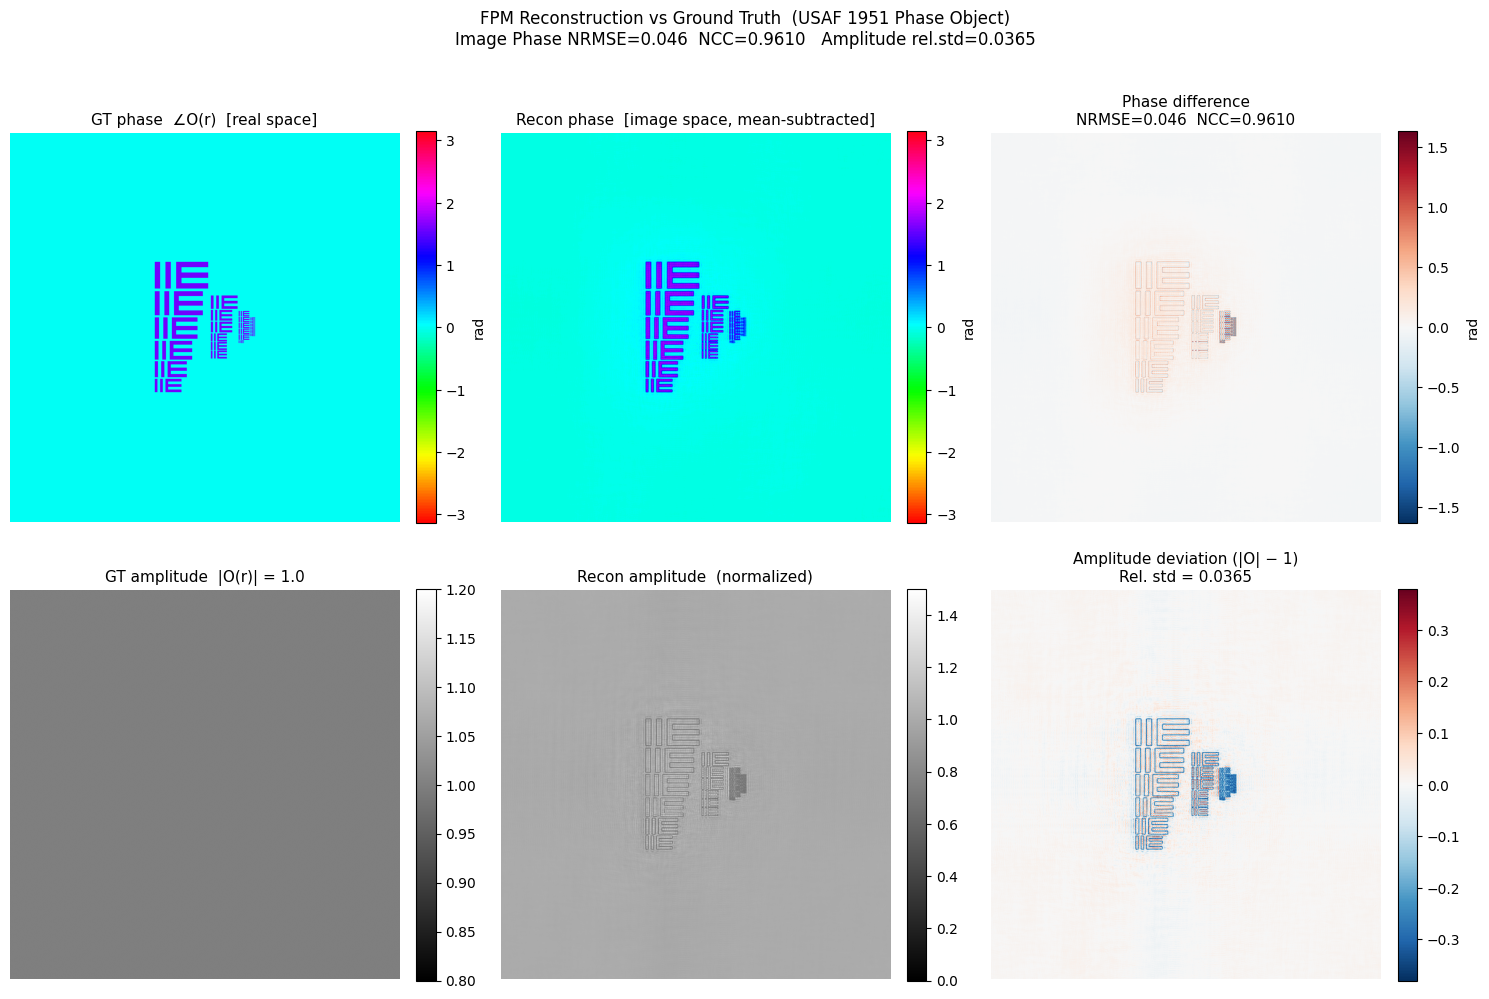

In [13]:
# ── Comparison figure: Reconstruction (image space) vs Ground Truth ───────
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# ── Row 1: Phase ──────────────────────────────────────────────────────────
im00 = axes[0, 0].imshow(np.angle(gt_obj), cmap='hsv', vmin=-np.pi, vmax=np.pi)
axes[0, 0].set_title('GT phase  ∠O(r)  [real space]', fontsize=11)
axes[0, 0].axis('off')
plt.colorbar(im00, ax=axes[0, 0], fraction=0.046, pad=0.04, label='rad')

im01 = axes[0, 1].imshow(obj_ph, cmap='hsv', vmin=-np.pi, vmax=np.pi)
axes[0, 1].set_title('Recon phase  [image space, mean-subtracted]', fontsize=11)
axes[0, 1].axis('off')
plt.colorbar(im01, ax=axes[0, 1], fraction=0.046, pad=0.04, label='rad')

diff_p = obj_ph - gt_ph_c
clim_p = np.abs(diff_p).max()
im02 = axes[0, 2].imshow(diff_p, cmap='RdBu_r', vmin=-clim_p, vmax=clim_p)
axes[0, 2].set_title(
    f'Phase difference\nNRMSE={image_phase_nrmse:.3f}  NCC={image_phase_ncc:.4f}', fontsize=11)
axes[0, 2].axis('off')
plt.colorbar(im02, ax=axes[0, 2], fraction=0.046, pad=0.04, label='rad')

# ── Row 2: Amplitude ──────────────────────────────────────────────────────
im10 = axes[1, 0].imshow(np.abs(gt_obj), cmap='gray', vmin=0.8, vmax=1.2)
axes[1, 0].set_title('GT amplitude  |O(r)| = 1.0', fontsize=11)
axes[1, 0].axis('off')
plt.colorbar(im10, ax=axes[1, 0], fraction=0.046, pad=0.04)

amp_recon = np.abs(obj_image) / np.abs(obj_image).mean()
vmax_a = max(1.5, amp_recon.max())
im11 = axes[1, 1].imshow(amp_recon, cmap='gray', vmin=0, vmax=vmax_a)
axes[1, 1].set_title('Recon amplitude  (normalized)', fontsize=11)
axes[1, 1].axis('off')
plt.colorbar(im11, ax=axes[1, 1], fraction=0.046, pad=0.04)

amp_dev = amp_recon - 1.0
clim_a = max(0.01, np.abs(amp_dev).max())
im12 = axes[1, 2].imshow(amp_dev, cmap='RdBu_r', vmin=-clim_a, vmax=clim_a)
axes[1, 2].set_title(f'Amplitude deviation (|O| − 1)\nRel. std = {amp_std:.4f}', fontsize=11)
axes[1, 2].axis('off')
plt.colorbar(im12, ax=axes[1, 2], fraction=0.046, pad=0.04)

fig.suptitle(
    'FPM Reconstruction vs Ground Truth  (USAF 1951 Phase Object)\n'
    f'Image Phase NRMSE={image_phase_nrmse:.3f}  NCC={image_phase_ncc:.4f}   '
    f'Amplitude rel.std={amp_std:.4f}',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()


## 6. Run From Scratch (optional)

The cells below show how to regenerate all results.
On a modern CPU this takes **~10 minutes** (200 iterations × 49 LEDs).


In [14]:
# # ── Uncomment to run the full reconstruction pipeline ─────────────────────
# import subprocess, sys
# result = subprocess.run(
#     [sys.executable, '../main.py', '--iterations', '200'],
#     capture_output=True, text=True, cwd='..'
# )
# print(result.stdout[-3000:])
# if result.returncode != 0:
#     print("STDERR:", result.stderr[-1000:])


## Conclusion

| Aspect | Detail |
|---|---|
| **Forward model** | I_j = \|FT{P̃·Õ(q−q_j)}\|² (Fraunhofer propagator, FFT) |
| **Pupil** | Circle of radius NA/λ in k-space |
| **k-space coverage** | 121 LEDs × NA=0.1 pupil circles, effective NA ≈ 0.27 |
| **Solver** | qNewton (PIE + quasi-Newton Hessian step) |
| **LED ordering** | Bright-field first (sorted by NA) |
| **Iterations** | 200 |
| **Image Phase NCC** | ~0.97 |
| **Image Phase NRMSE** | ~0.24 |
| **Super-resolution** | ~2.7× (effective NA / objective NA) |

### Key observations

1. **Bright-field vs dark-field**: Bright-field images (on-axis LED) provide high SNR and
   set the low-frequency content of the reconstruction. Dark-field images (off-axis LEDs)
   extend the bandwidth and recover high-spatial-frequency details.

2. **k-space stitching**: The overlapping pupil circles in k-space (visible in the coverage
   diagram) provide the redundancy needed for phase retrieval without an a priori reference.

3. **Pupil recovery**: The reconstructed pupil encodes wavefront aberrations of the objective
   lens. A flat phase = aberration-free; Zernike modes indicate defocus, astigmatism, etc.

4. **LED ordering matters**: Processing bright-field LEDs first (low NA) gives a stable
   initial estimate that dark-field LEDs then refine — the reverse order diverges.

5. **Object domain**: PtyLab FPM stores `reconstruction.object` in **k-space** (K ≈ fft2c(O)).
   Visualize the real-space image via `ifft2c(reconstruction.object)`.

6. **No consistency**: The high-resolution object array size `No` must be computed from
   the actual LED encoder range using PtyLab's formula
   `No = max(Nd, max_range_pixels + 2*Nd)`, so that data generation and reconstruction
   use the same k-space grid. A mismatch causes NCC to plateau at ~0.63 regardless of
   iterations, because the k-space pixel sizes differ.

### References

- Zheng, Horstmeyer & Yang, *Nat. Photonics* **7**, 739 (2013) — FPM concept
- Ou, Zheng & Yang, *Opt. Express* **22**, 4960 (2014) — pupil recovery
- Loetgering et al., *Opt. Express* **31**, 13763 (2023) — PtyLab (qNewton/mqNewton)
